In [1]:
import types
import sys
from numbers import Real, Integral

# Create a fake module to emulate 'sklearn.utils._param_validation'
# (used by skglm in newer versions of scikit-learn, >=1.3)
param_validation = types.ModuleType("sklearn.utils._param_validation")

# Define a minimal replacement for Interval used in _parameter_constraints
class Interval:
    def __init__(self, dtype, left, right, closed="neither"):
        self.dtype = dtype
        self.left = left
        self.right = right
        self.closed = closed

# Define a minimal replacement for StrOptions used in _parameter_constraints
class StrOptions:
    def __init__(self, options):
        self.options = set(options)

# Add the custom classes to the fake module
param_validation.Interval = Interval
param_validation.StrOptions = StrOptions

# Inject the fake module into sys.modules before skglm is imported
# This prevents skglm from raising an ImportError if sklearn < 1.3
sys.modules["sklearn.utils._param_validation"] = param_validation

In [2]:
import os

# Add the src directory to the Python path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import our custom modules
from utils import *
from compression_pkg import *
from survival_analysis_sigbert import *
from descriptive_stats_pkg import *

# I) Data Importation

In [3]:
df_all = pd.read_parquet("../data/df_mimic_L36_w24.parquet",engine="pyarrow")

In [4]:
df_all.head(3)

,SUBJECT_ID,note_time,event,death_time,time_since_first_note,survival_time,report_word_count,Ti,delta_i,embeddings
0,20,2183-04-16,0,None,0,23.0,81,23.0,0,"[-0.0018343869596719742, -0.021196581423282623..."
1,20,2183-04-22,0,None,6,23.0,24,23.0,0,"[0.009556187316775322, 0.0020295430440455675, ..."
2,20,2183-04-22,0,None,6,23.0,134,23.0,0,"[0.003625504206866026, -0.027227500453591347, ..."


In [5]:
# Train-Test Split
df_train_new_OG, test_groups = make_train_test(df_all)

Initial rows: 456330
Initial patients: 9644
Patients after date filtering: 9644
Training patients: 4822
Test group 1: 483 patients
Test group 2: 483 patients
Test group 3: 482 patients
Test group 4: 482 patients
Test group 5: 482 patients
Test group 6: 482 patients
Test group 7: 482 patients
Test group 8: 482 patients
Test group 9: 482 patients
Test group 10: 482 patients


# Descriptives Stats

In [6]:
print_dataset_statistics(df_all, var_id="SUBJECT_ID", var_death='event')

Total number of patients: 9644
Total number of medical reports: 456330
Average number of reports per patient: 47.32
Number of deceased patients: 3635
Number of censored patients: 6009


## Distributions of reports number

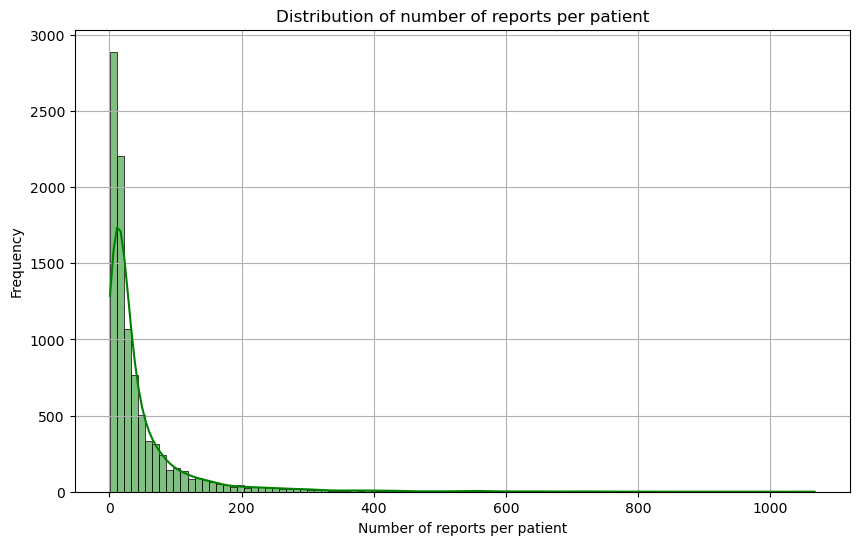

Total number of patients: 9644
Mean number of reports per patient: 47.32 (sd 79.71).
Median number of reports per patient: 21.00
Maximum number of reports for a single patient: 1067


In [7]:
report_counts = plot_reports_per_patient_distribution(
    df=df_all,
    id_column="SUBJECT_ID",
    bins=100,
    kde=True,
    color="green",
    save_path=None,#"../results/descriptive_statistics/nbr_reports_per_patients.png",
    verbose=True
)

## Distribution of study duration

In [8]:
columns_to_keep = [
    "delta_i",
    "death_time",
    "survival_time",
    "Ti",
    "date_start",
    "date_end",
    "duration"
]

df_info = make_df_info(
    df=df_all,
    columns_to_keep=columns_to_keep,
    var_id="SUBJECT_ID",
    var_time="note_time",
    verbose=True
)

Number of patients: 9644
Mean observation period: 208.19 days
Median observation period: 18.00 days


In [9]:
df_info.head(2)

,SUBJECT_ID,delta_i,death_time,survival_time,Ti,date_start,date_end,duration
0,2,0,None,0.0,0.0,2138-07-17,2138-07-17,0.0
1,3,1,2102-06-14,251.0,251.0,2101-10-06,2102-04-18,194.0


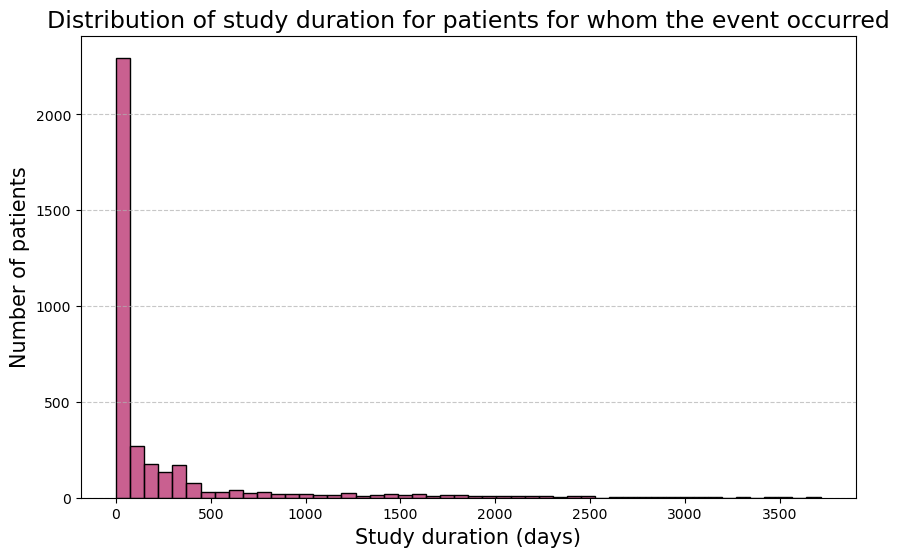

Summary statistics for event cases:
count    3635.000000
mean      257.881431
std       547.342199
min         0.000000
25%         9.000000
50%        32.000000
75%       217.000000
max      3716.000000
Name: duration, dtype: float64


In [10]:
df_deceased, summary_stats = plot_event_duration_distribution(
    df_info=df_info,
    event_column="delta_i",
    duration_column="duration",
    event_value=1,
    bins=50,
    save_path=None,#"../results/descriptive_statistics/duration_distribution.png",
    verbose=True
)

## Kaplan Meier Curves : Train Vs Validation

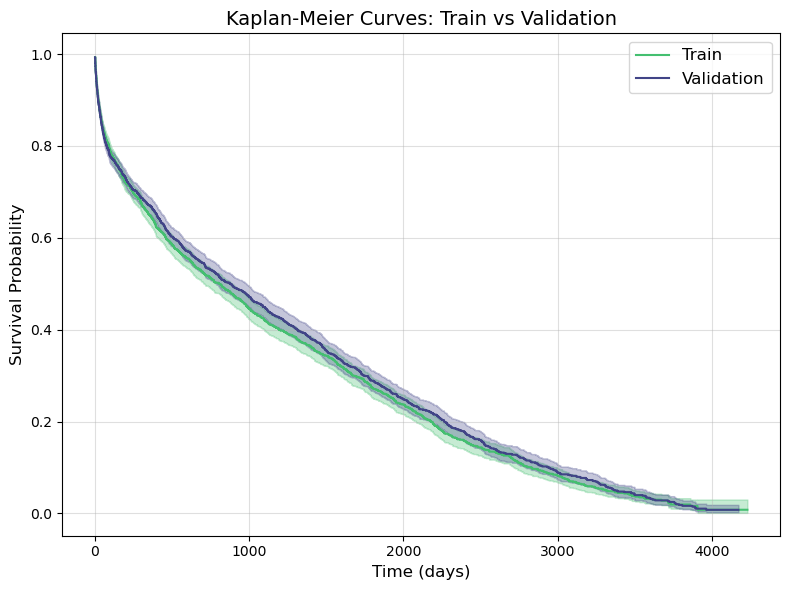

Train cohort size: 4822 patients
Validation cohort size: 4822 patients
Train events: 1837
Validation events: 1798

Log-rank test:
   test_statistic         p  -log2(p)
0        1.095862  0.295176  1.760353
Log-rank p-value: 0.2952

Median event time (Train): 302.00 days
Median event time (Validation): 332.00 days


In [12]:
(
    df_info_train,
    df_info_validation,
    logrank_results,
    median_event_time_train,
    median_event_time_validation
) = plot_km_train_vs_validation_with_logrank(
    df_info=df_info,
    id_column="SUBJECT_ID",
    duration_column="survival_time",
    event_column="delta_i",
    df_train=df_train_new_OG,
    test_groups=test_groups,
    title="Kaplan-Meier Curves: Train vs Validation"
)